In [3]:
from util.DataGen import *
from util.Plotting import *
from util.Processing import *
from util.metrics import *
from  scipy.signal import find_peaks

import numpy as np
import matplotlib.pyplot as plt


250.0 Photons
mV_per_keV 0.12907739940993107
(2001,) (2001,) (250,) (250,)
(653,)


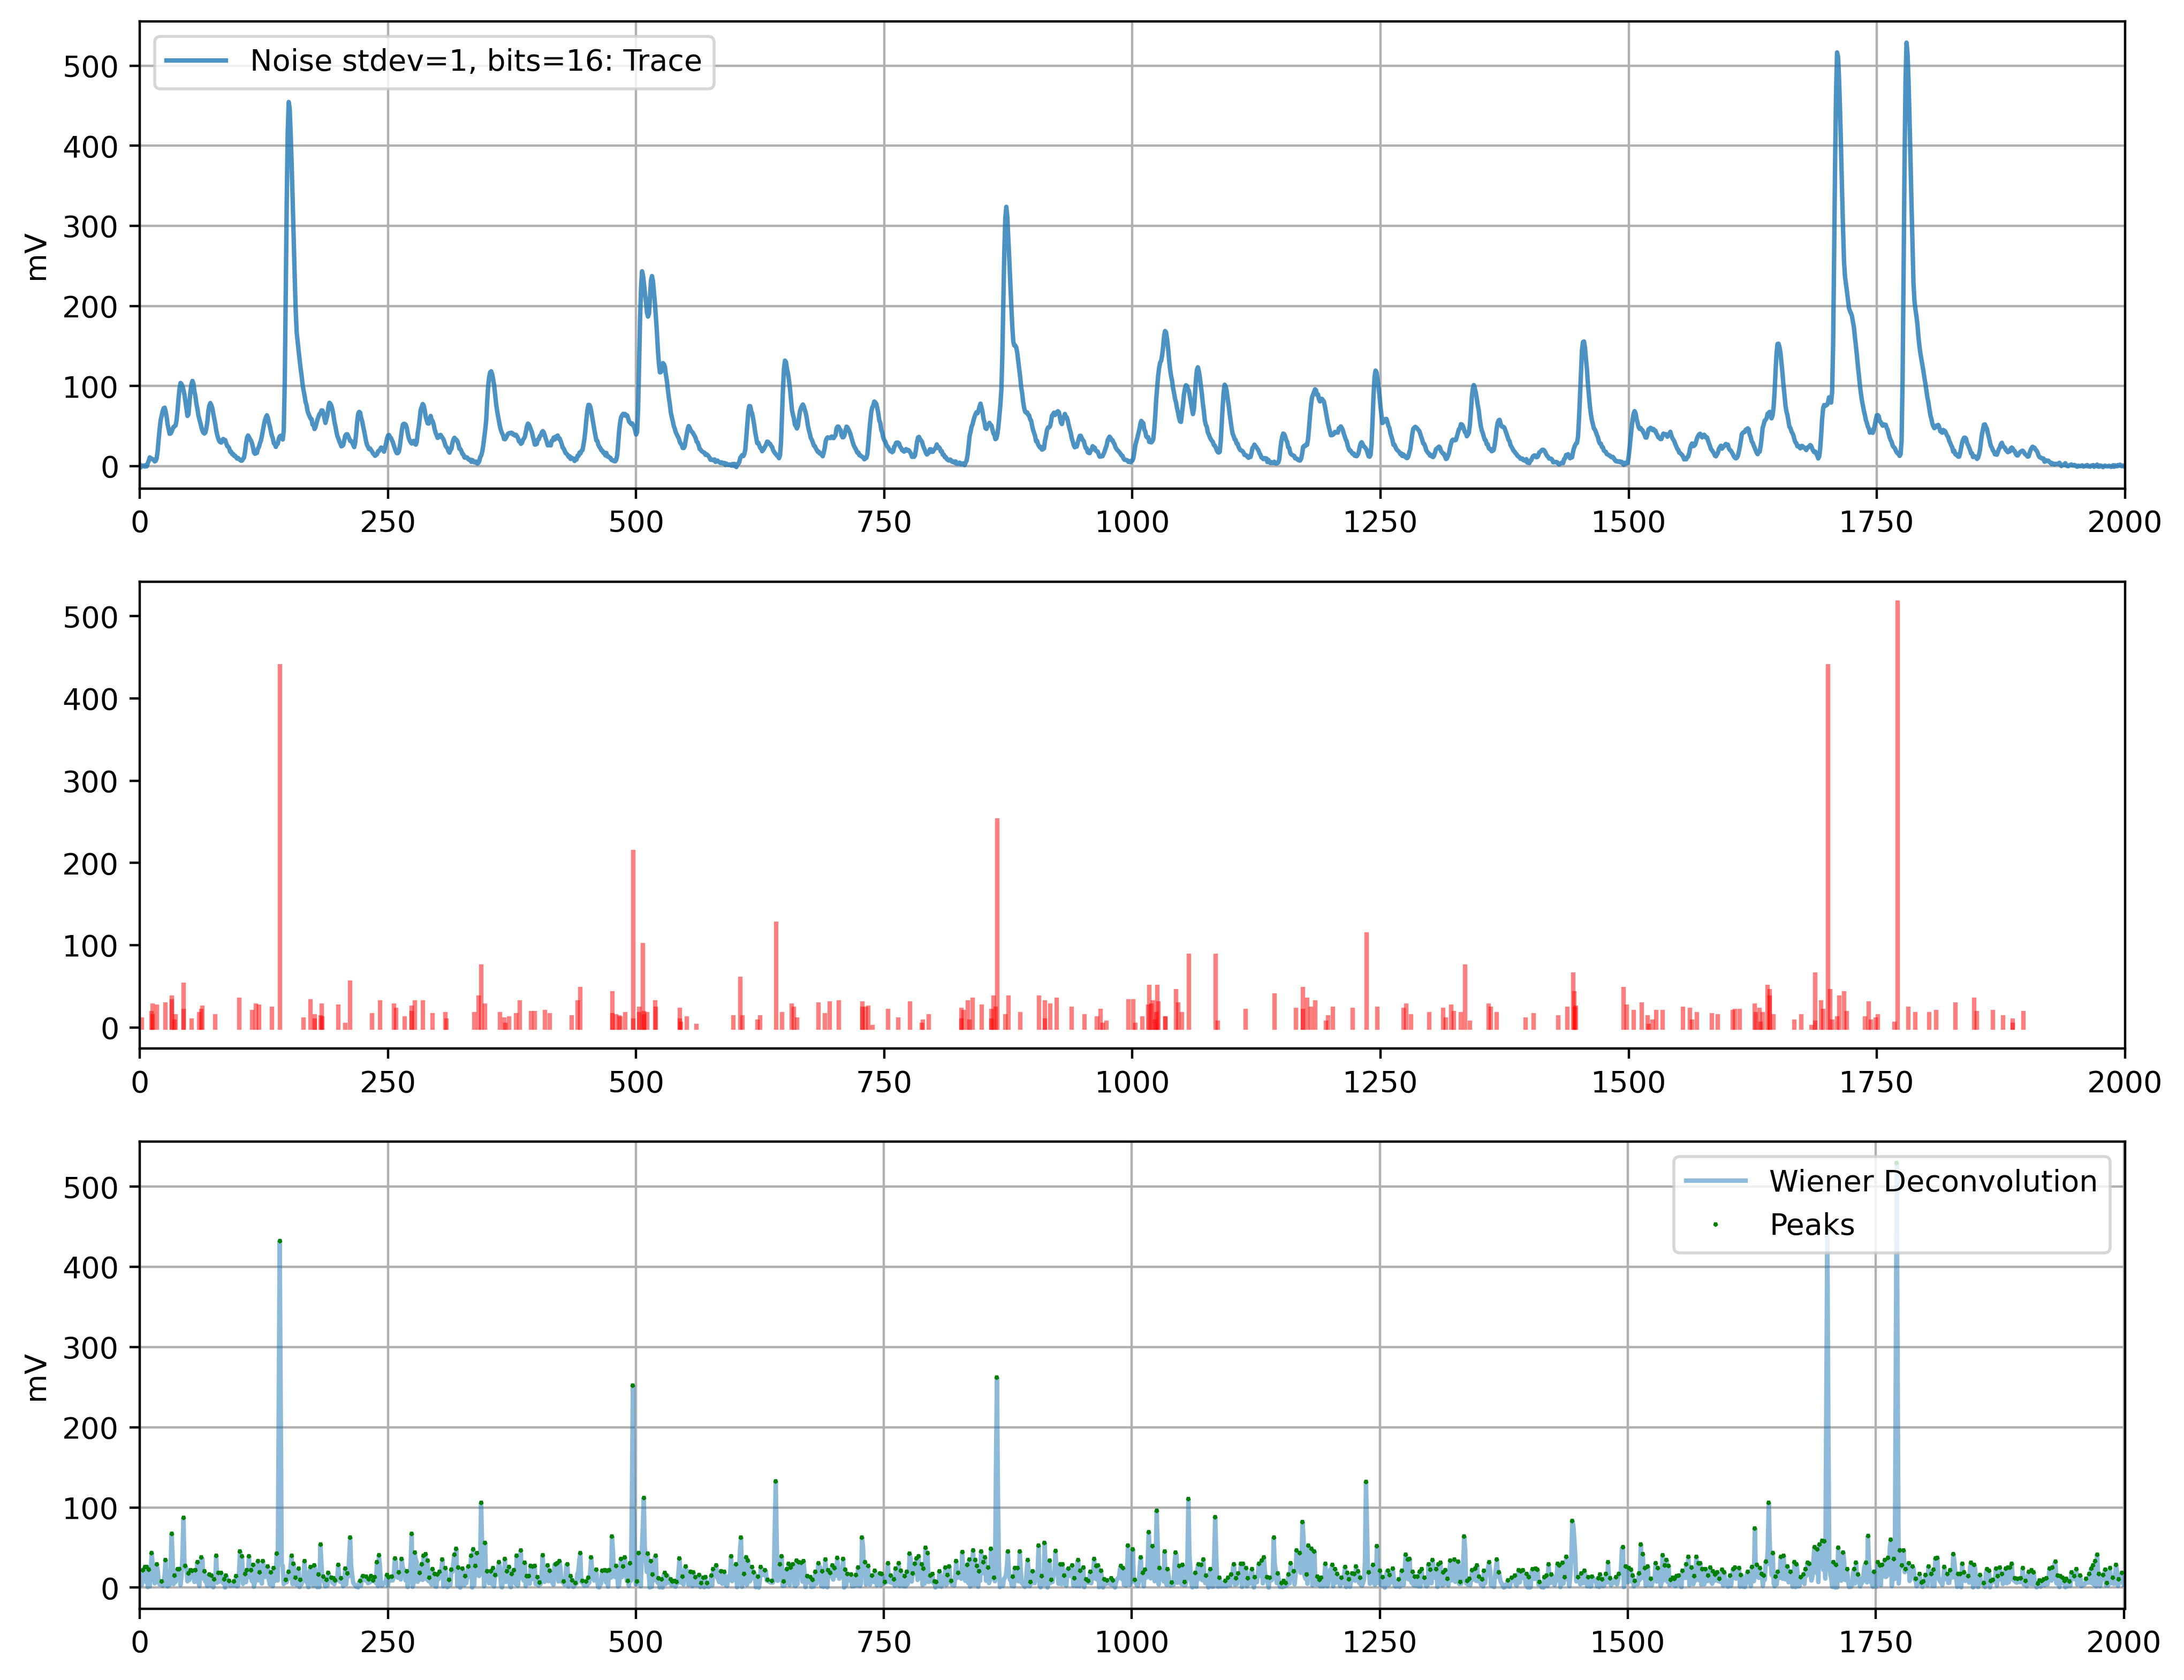

In [9]:
# Trace
seed = 3
countrate = 5e6
total_time = 5e-5

# Sensor
noise_stdev = 1 # mV
bits = 16 # 8 bits is
K = 1e-3
correction_factor = 1/.55
# correction_factor = 1 # to find right CR...
threshold = 5

print('{} Photons'.format(countrate * total_time) )

dt = np.float64(25e-9) #sampling rate in seconds. 40MHz
sampling_ratio = 1
_, kernel = nai_pulse(1, 101, sampling_ratio)

spectrum = np.loadtxt('../original/NaI_Response',usecols=(1), dtype=float)
bins = 1e3 * np.loadtxt('../original/NaI_Response',usecols=(0), dtype=float) # in mV

keV_per_area = .147 #determined by trial and error to match energy range of instrument 
mV_per_ADC = 1000./4096.
area_per_peak = np.sum(kernel)/max(kernel)
mV_per_keV = mV_per_ADC/(keV_per_area*area_per_peak)
print('mV_per_keV', mV_per_keV)


#########################################################################################################################
# Spectrum trace
trace, time_vector, volts_list, volts_time_index = spectrum_trace(
                                                    count_rate_=countrate, dt_=dt, total_time_=total_time,
                                                    pulse_=kernel, bin_energies_=bins, spectrum_=spectrum,
                                                    mV_per_keV_=mV_per_keV, noise_std_=noise_stdev, baseline_=0,
                                                    sampling_ratio_=sampling_ratio, discretize=True, bits_=bits,
                                                    seed_=seed, clip=False, debug=False)

print(
    trace.shape,
    time_vector.shape,
    volts_list.shape,
    volts_time_index.shape,
)

##########################################################################################################################
    
N = trace.size
trace_fft_noise = trace

fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=400)
fig.tight_layout()
axes[0].plot(trace_fft_noise, label='Noise stdev={}, bits={}: Trace'.format(noise_stdev, bits), alpha=.8)
xlim = [0, 2000]
axes[0].set_xlim(xlim)
axes[0].legend(loc=1)
axes[0].set_ylabel('mV')
axes[0].grid()
axes[0].legend()

plot_photons(axes[1], volts_time_index, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
axes[1].set_xlim(xlim)

wiener_deconv_noise_quantized = wiener_deconvolve(trace_fft_noise, kernel, K)
wiener_deconv_noise_quantized *= correction_factor
# plot_photons(axes[1], volts_time_indeces, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
axes[2].plot(wiener_deconv_noise_quantized, label='Wiener Deconvolution', alpha=.5)
# axes[1].set_ylim([0, np.max(trace)])
axes[2].set_xlim([0, N])
# peaks
peaks, _ = find_peaks(wiener_deconv_noise_quantized, height=threshold)
print(peaks.shape)
peak_vals = wiener_deconv_noise_quantized[peaks]
axes[2].plot(peaks, peak_vals, 'g*', markersize='1', label='Peaks')
axes[2].legend(loc=1)
axes[2].set_ylabel('mV')
axes[2].grid()




Stats
Count rate: 5.00E+06, time: 5.00E-05, bits: 24, Noise stdev: 0, K: 0.001
Coincident Photons: 7.60%, Coincident Energy: 13.79732%

Detection:
True Photons: 250 Detected Photons: 695
Counted Photons: 278.00%, Counted Energy: 221.27501%
done


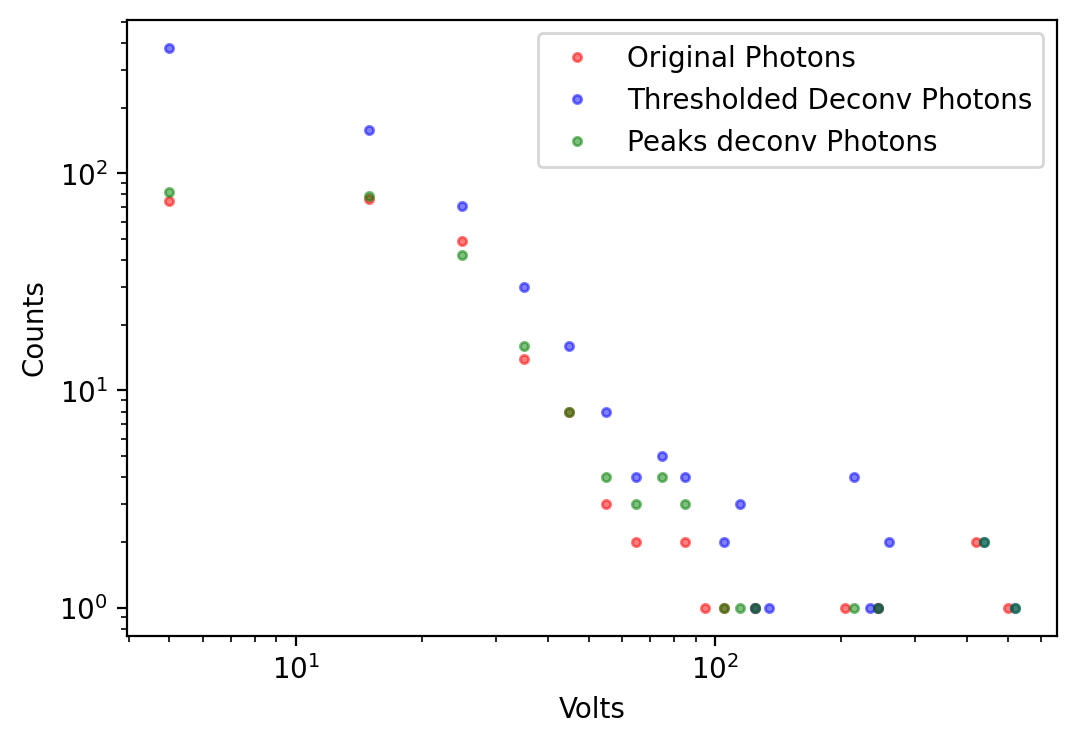

In [5]:
#Stats
print('Stats')
print("Count rate: {:.2E}, time: {:.2E}, bits: {}, Noise stdev: {}, K: {}".format(countrate, total_time, bits, noise_stdev, K))

coincident_photons_pct, coincident_energy_pct = coincident_pct(volts_time_index, volts_list, time_vector)
print("Coincident Photons: {:.2f}%, Coincident Energy: {:.5f}%".format(coincident_photons_pct*100, coincident_energy_pct*100))


# Summed volts list values
summed_index_list, summed_volts_list = summed_listmode(volts_time_index, volts_list, time_vector)

# Detect Photons...
print('\nDetection:')
thresholded_volts_list, thresholded_indeces = threshold_listmode(wiener_deconv_noise_quantized, threshold)
print('True Photons:', volts_list.size, 'Detected Photons:', thresholded_volts_list.size)

photons_counted = photons_counted_pct(thresholded_indeces, volts_time_index)
energy_counted = volts_counted_pct(thresholded_volts_list, volts_list)
print("Counted Photons: {:.2f}%, Counted Energy: {:.5f}%".format(photons_counted*100, energy_counted*100))

# Histograms by Magnitude
original_counts, original_values, wiener_counts, counted_values = volts_counted_hist(volts_list, thresholded_volts_list, bins=bins)

#Peaks
_, _, peak_counts, _ = volts_counted_hist(volts_list, peak_vals, bins=bins)

plt.figure(figsize=(6,4), dpi=200)
# print(bins.size, original_counts.size)
original_gt0 = np.where(original_counts > 0)[0]
wiener_gt0 = np.where(wiener_counts > 0)[0]
peaks_gt0 = np.where(peak_counts > 0)[0]

plt.plot(bins[:-1][original_gt0], original_counts[original_gt0], label='Original Photons', linestyle='', marker='.', color='r', alpha =.5)
plt.plot(bins[:-1][wiener_gt0], wiener_counts[wiener_gt0], label='Thresholded Deconv Photons', linestyle='', marker='.', color='b', alpha =.5)
plt.plot(bins[:-1][peaks_gt0], peak_counts[peaks_gt0], label='Peaks deconv Photons', linestyle='', marker='.', color='g', alpha =.5)

# plt.xlim([0, 300])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volts')
plt.ylabel('Counts')
plt.legend()
print('done')



In [6]:
# print(bins)
# v_bins = bins/mV_per_keV
# print(v_bins)
# discretized_v_space = discretize(v_space, bits=bits)
# 
# plt.figure()
# plt.plot(v_bins)
# plt.show()

Deconv Ratio percentiles 0->100: [ 0.20859254  0.81526918  0.9260885   0.97129258  1.01284303  1.03244285
  1.06445216  1.10056817  1.19046537  1.55786486 19.4584199 ]
True Photons: 250 Detected Photons: 695
done


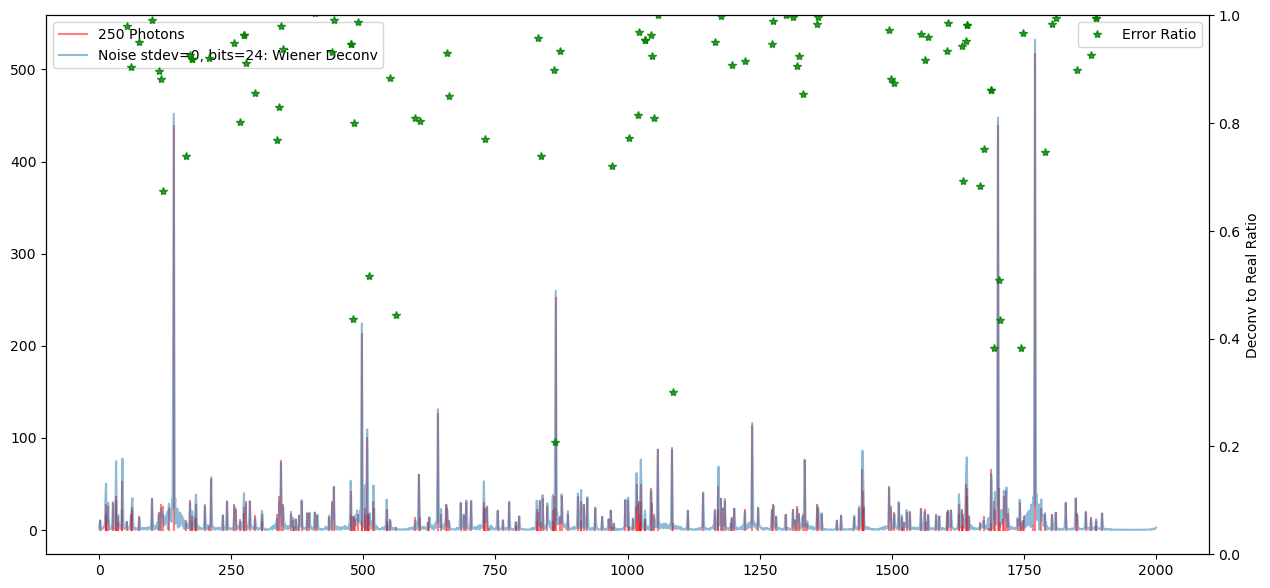

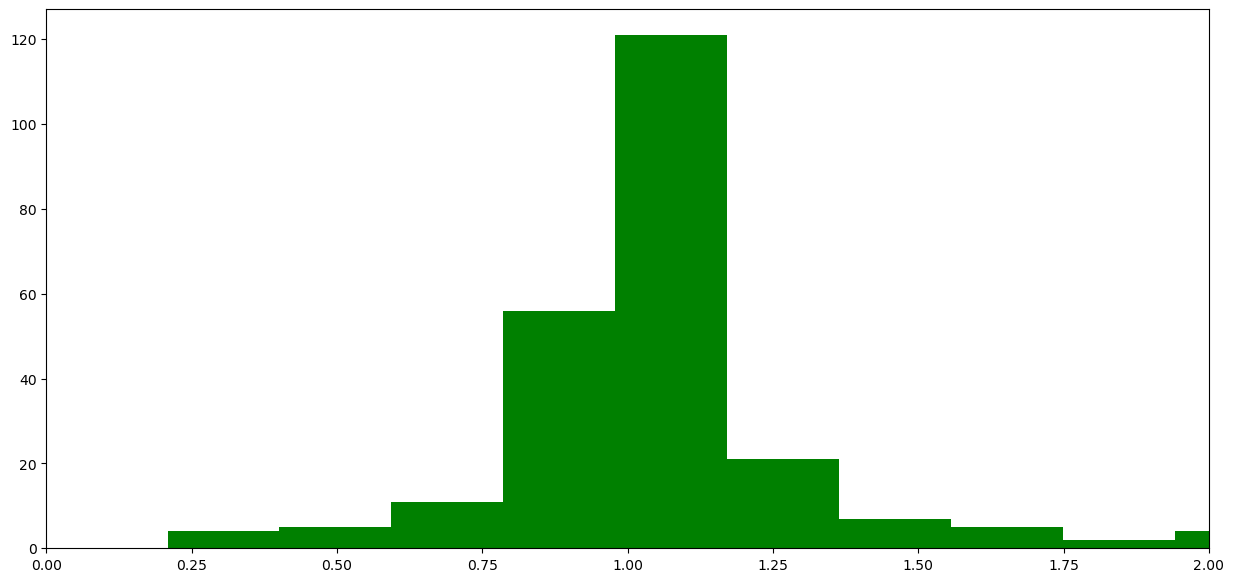

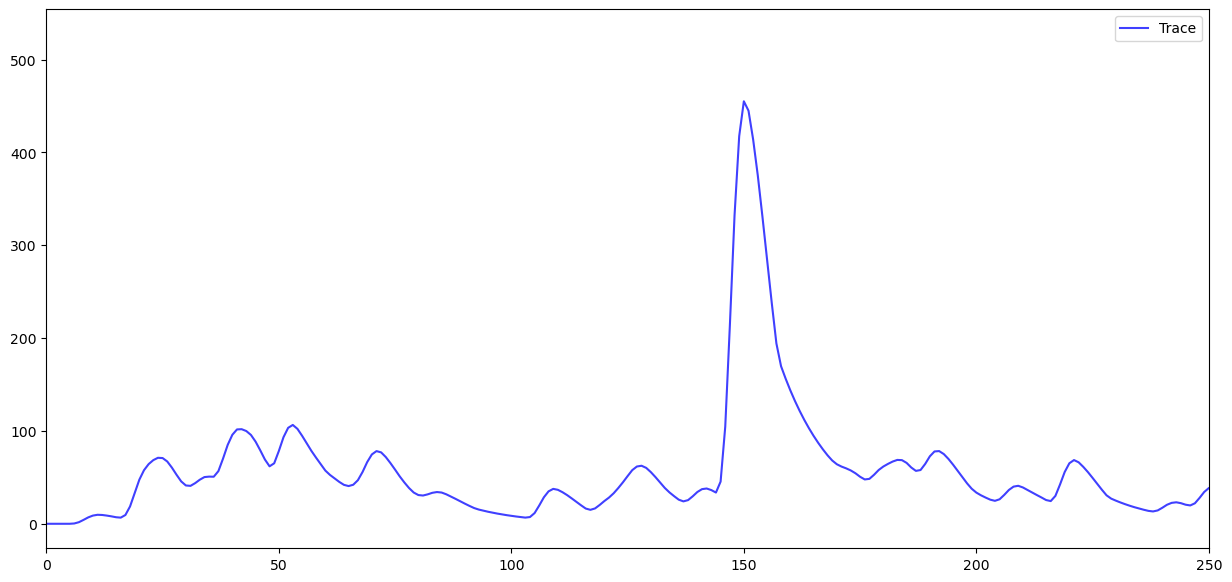

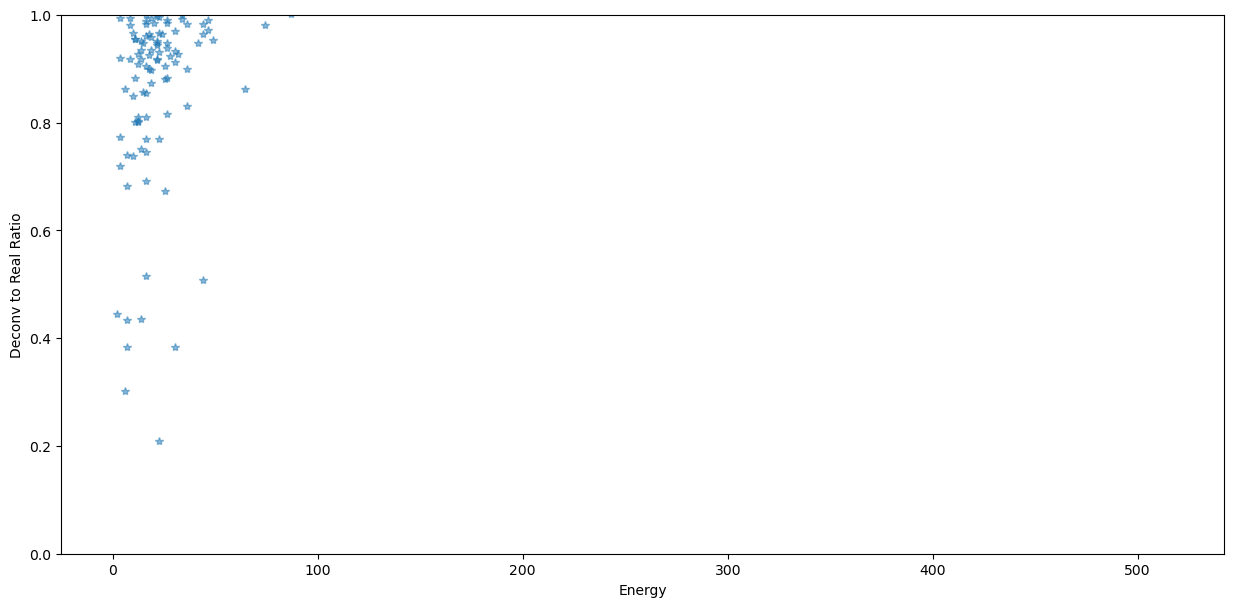

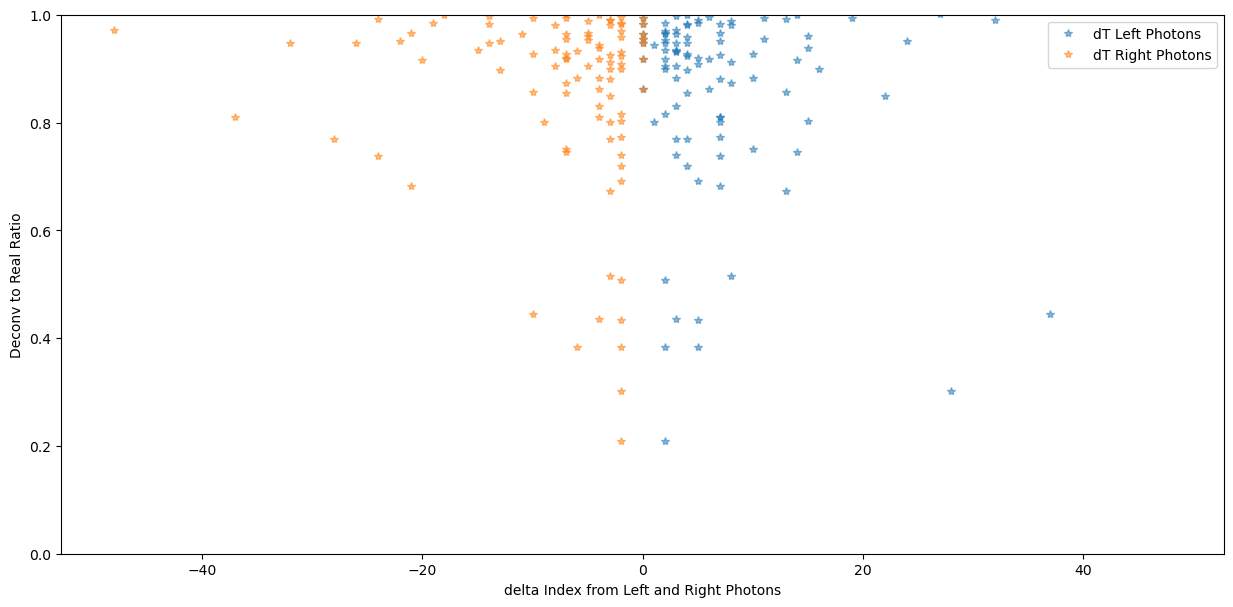

In [7]:
# investigate relative error using thresholding method

photon_list_vector_mode = np.zeros(trace.size)
for i, v in zip(summed_index_list, summed_volts_list):
    photon_list_vector_mode[i] += v
wiener_error_ratio = wiener_deconv_noise_quantized[volts_time_index] / photon_list_vector_mode[volts_time_index]

# print('Mean Ratio:', np.mean(wiener_error_ratio), ' STD(ratio):', np.std(wiener_error_ratio))
print('Deconv Ratio percentiles 0->100:', np.percentile(wiener_error_ratio, np.linspace(0, 100, 11)))

fig, axes = plt.subplots(1,1)
plot_photons(axes, volts_time_index, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
axes.plot(wiener_deconv_noise_quantized, label='Noise stdev={}, bits={}: Wiener Deconv'.format(noise_stdev, bits), alpha=.5)
axes.legend(loc='upper left')

right_axis = axes.twinx()
right_axis.plot(volts_time_index, wiener_error_ratio, 'g*',label='Error Ratio', alpha=.8)
right_axis.set_ylabel('Deconv to Real Ratio')
right_axis.set_ylim([0, 1])
right_axis.legend(loc='upper right')

plt.figure()
plt.hist(wiener_error_ratio, bins=100, color='g')
plt.xlim(0, 2)


threshold = 5
thresholded_volts, thresholded_indeces = threshold_listmode(wiener_deconv_noise_quantized, threshold)
plt.figure()
# plt.plot(volts_time_indeces, volts_list/volts_list, 'b*', label='True Photons', alpha=1)
plt.plot(trace, 'b', label='Trace', alpha=.75)
# plt.plot(thresholded_indeces, thresholded_volts/thresholded_volts, 'r*', label='Detected Photons', alpha=1)
plt.plot()
plt.xlim(0, 250)
plt.legend()
print('True Photons:', volts_list.size, 'Detected Photons:', thresholded_volts.size)

ylim = [0,1]
plt.figure()
plt.plot(volts_list , wiener_error_ratio, marker='*', linestyle='', alpha=.5)
plt.xlabel('Energy')
plt.ylabel('Deconv to Real Ratio')
plt.yscale('linear')
plt.ylim(ylim[0], ylim[1])
plt.ylim(0,1)
plt.xscale('linear')

# TODO use scipy nearest neighbor

delta_left = np.diff(volts_time_index)
delta_right = np.diff(volts_time_index[::-1])
plt.figure()
plt.plot(delta_left , wiener_error_ratio[:-1], marker='*', linestyle='',label='dT Left Photons', alpha=.5)
plt.plot(delta_right , (wiener_error_ratio[1:])[::-1], marker='*', linestyle='', label='dT Right Photons', alpha=.5)
plt.xlabel('delta Index from Left and Right Photons')
plt.ylabel('Deconv to Real Ratio')
plt.yscale('linear')
plt.legend()
plt.ylim(ylim[0], ylim[1])
print('done')


In [8]:
# TODO
# # investigate relative error using peak finding method...
# peaks, _ = find_peaks(wiener_deconv_noise_quantized, height=threshold)
# print(peaks.shape)
# peak_vals = wiener_deconv_noise_quantized[peaks]
# 
# # photon_list_vector_mode = np.zeros(trace.size)
# # for i, v in zip(summed_index_list, summed_volts_list):
# #     photon_list_vector_mode[i] += v
# # wiener_error_ratio = wiener_deconv_noise_quantized[volts_time_index] / photon_list_vector_mode[volts_time_index]
# 
# # print('Mean Ratio:', np.mean(wiener_error_ratio), ' STD(ratio):', np.std(wiener_error_ratio))
# print('Deconv Ratio percentiles 0->100:', np.percentile(wiener_error_ratio, np.linspace(0, 100, 11)))
# 
# fig, axes = plt.subplots(1,1)
# plot_photons(axes, volts_time_index, volts_list, label_='{} Photons'.format(len(volts_list)), color='r', alpha=.5)
# axes.plot(wiener_deconv_noise_quantized, label='Noise stdev={}, bits={}: Wiener Deconv'.format(noise_stdev, bits), alpha=.5)
# axes.legend(loc='upper left')
# 
# right_axis = axes.twinx()
# right_axis.plot(volts_time_index, wiener_error_ratio, 'g*',label='Error Ratio', alpha=.8)
# right_axis.set_ylabel('Deconv to Real Ratio')
# right_axis.set_ylim([0, 1])
# right_axis.legend(loc='upper right')
# 
# plt.figure()
# plt.hist(wiener_error_ratio, bins=100, color='g')
# plt.xlim(0, 2)
# 
# 
# threshold = 5
# thresholded_volts, thresholded_indeces = threshold_listmode(wiener_deconv_noise_quantized, threshold)
# plt.figure()
# # plt.plot(volts_time_indeces, volts_list/volts_list, 'b*', label='True Photons', alpha=1)
# plt.plot(trace, 'b', label='Trace', alpha=.75)
# # plt.plot(thresholded_indeces, thresholded_volts/thresholded_volts, 'r*', label='Detected Photons', alpha=1)
# plt.plot()
# plt.xlim(0, 250)
# plt.legend()
# print('True Photons:', volts_list.size, 'Detected Photons:', thresholded_volts.size)
# 
# ylim = [0,1]
# plt.figure()
# plt.plot(volts_list , wiener_error_ratio, marker='*', linestyle='', alpha=.5)
# plt.xlabel('Energy')
# plt.ylabel('Deconv to Real Ratio')
# plt.yscale('linear')
# plt.ylim(ylim[0], ylim[1])
# plt.ylim(0,1)
# plt.xscale('linear')
# 
# # TODO use scipy nearest neighbor
# 
# delta_left = np.diff(volts_time_index)
# delta_right = np.diff(volts_time_index[::-1])
# plt.figure()
# plt.plot(delta_left , wiener_error_ratio[:-1], marker='*', linestyle='',label='dT Left Photons', alpha=.5)
# plt.plot(delta_right , (wiener_error_ratio[1:])[::-1], marker='*', linestyle='', label='dT Right Photons', alpha=.5)
# plt.xlabel('delta Index from Left and Right Photons')
# plt.ylabel('Deconv to Real Ratio')
# plt.yscale('linear')
# plt.legend()
# plt.ylim(ylim[0], ylim[1])
# print('done')
